## Problématique Business

La fraude à la carte bancaire représente des milliards de pertes annuelles pour les institutions financières. Détecter automatiquement les transactions suspectes en temps réel permet de :
- Réduire les pertes financières liées aux transactions non autorisées
- Améliorer l'expérience client en évitant les blocages injustifiés
- Automatiser la surveillance des millions de transactions quotidiennes

Le défi principal est le fort déséquilibre de classes : les fraudes représentent moins de 1% des transactions.

## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
# Style global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

## 2. Chargement des données

In [2]:
df = pd.read_csv('fraudTrain.csv')

# Suppression de la colonne index automatique
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)
display(df.head(5))

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,1/1/2019 0:00,2.703186e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",3/9/1988,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0
1,1/1/2019 0:00,NaN,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,6/21/1978,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0
2,1/1/2019 0:00,3.885950e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1/19/1962,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0
3,1/1/2019 0:01,3.534094e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1/12/1967,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0
4,1/1/2019 0:03,3.755340e+14,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,3/28/1986,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0


## 3. Structure & Types des données

In [3]:
print('=== Informations générales ===')
df.info()
print(f'\nShape : {df.shape}')

=== Informations générales ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1048573 non-null  object 
 1   cc_num                 1048573 non-null  float64
 2   merchant               1048575 non-null  object 
 3   category               1048575 non-null  object 
 4   amt                    1048575 non-null  float64
 5   first                  1048575 non-null  object 
 6   last                   1048575 non-null  object 
 7   gender                 1048575 non-null  object 
 8   street                 1048575 non-null  object 
 9   city                   1048575 non-null  object 
 10  state                  1048575 non-null  object 
 11  zip                    1048575 non-null  int64  
 12  lat                    1048575 non-null  float64
 13  long                   1048575 non-null  

In [4]:
print('=== Types de données ===')
type_counts = df.dtypes.value_counts()
print(type_counts)

print('Texte :', df.select_dtypes(include='object').columns.tolist())

=== Types de données ===
object     12
float64     8
int64       2
Name: count, dtype: int64
Texte : ['trans_date_trans_time', 'merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num']


## 4. Statistiques descriptives

In [5]:
print('=== Statistiques descriptives — Variables numériques ===')
display(df.describe().round(2))

=== Statistiques descriptives — Variables numériques ===


,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.048573e+06,1048575.00,1048575.00,1048575.00,1048575.00,1048575.00,1.048574e+06,1048574.00,1048574.00,1048574.00
mean,4.171617e+17,70.28,48801.50,38.53,-90.23,89058.54,1.344906e+09,38.53,-90.23,0.01
std,1.308819e+18,159.95,26897.95,5.08,13.76,302435.71,1.019700e+07,5.11,13.77,0.08
min,6.041621e+10,1.00,1257.00,20.03,-165.67,23.00,1.325376e+09,19.03,-166.67,0.00
25%,1.800400e+14,9.64,26237.00,34.62,-96.80,743.00,1.336682e+09,34.73,-96.90,0.00
50%,3.520550e+15,47.45,48174.00,39.35,-87.48,2456.00,1.344902e+09,39.36,-87.44,0.00
75%,4.642255e+15,83.05,72042.00,41.94,-80.16,20328.00,1.354366e+09,41.96,-80.23,0.00
max,4.992346e+18,28948.90,99783.00,66.69,-67.95,2906700.00,1.362932e+09,67.51,-66.95,1.00


In [6]:
print('=== Analyse du montant (amt) ===')
df.amt.describe().apply(lambda x: format(x, '.6f'))

=== Analyse du montant (amt) ===


count    1048575.000000
mean          70.279430
std          159.951964
min            1.000000
25%            9.640000
50%           47.450000
75%           83.050000
max        28948.900000
Name: amt, dtype: object

## 5. Valeurs manquantes & Doublons

=== Valeurs manquantes ===


,Valeurs manquantes,Pourcentage (%)
trans_date_trans_time,2,0.0002
cc_num,2,0.0002
job,1,0.0001
dob,2,0.0002
trans_num,1,0.0001
unix_time,1,0.0001
merch_lat,1,0.0001
merch_long,1,0.0001
is_fraud,1,0.0001


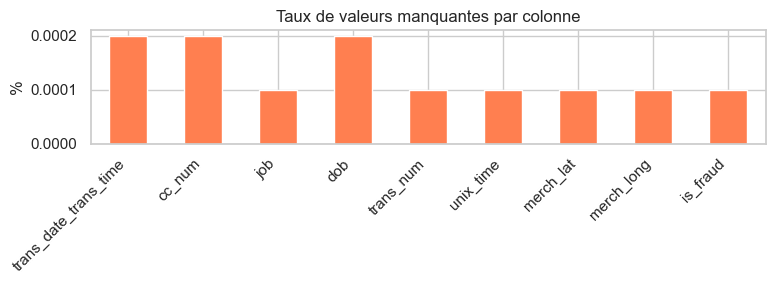


=== Doublons ===
6 doublon(s) trouvé(s)
Doublons supprimés — nouveau shape : (1048569, 22)


In [7]:
print('=== Valeurs manquantes ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct.round(4)
})
missing_with_vals = missing_df[missing_df['Valeurs manquantes'] > 0]

if len(missing_with_vals) > 0:
    display(missing_with_vals)
    
    # Visualisation
    plt.figure(figsize=(8, 3))
    missing_with_vals['Pourcentage (%)'].plot(kind='bar', color='coral')
    plt.title('Taux de valeurs manquantes par colonne')
    plt.ylabel('%')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('Aucune valeur manquante détectée')

# Doublons
n_dup = df.duplicated().sum()
print(f'\n=== Doublons ===\n{n_dup} doublon(s) trouvé(s)')
if n_dup > 0:
    df = df.drop_duplicates()
    print(f'Doublons supprimés — nouveau shape : {df.shape}')


## 6. Visualisations & Distributions

array([[<Axes: title={'center': 'cc_num'}>,
        <Axes: title={'center': 'amt'}>, <Axes: title={'center': 'zip'}>],
       [<Axes: title={'center': 'lat'}>,
        <Axes: title={'center': 'long'}>,
        <Axes: title={'center': 'city_pop'}>],
       [<Axes: title={'center': 'unix_time'}>,
        <Axes: title={'center': 'merch_lat'}>,
        <Axes: title={'center': 'merch_long'}>],
       [<Axes: title={'center': 'is_fraud'}>, <Axes: >, <Axes: >]],
      dtype=object)

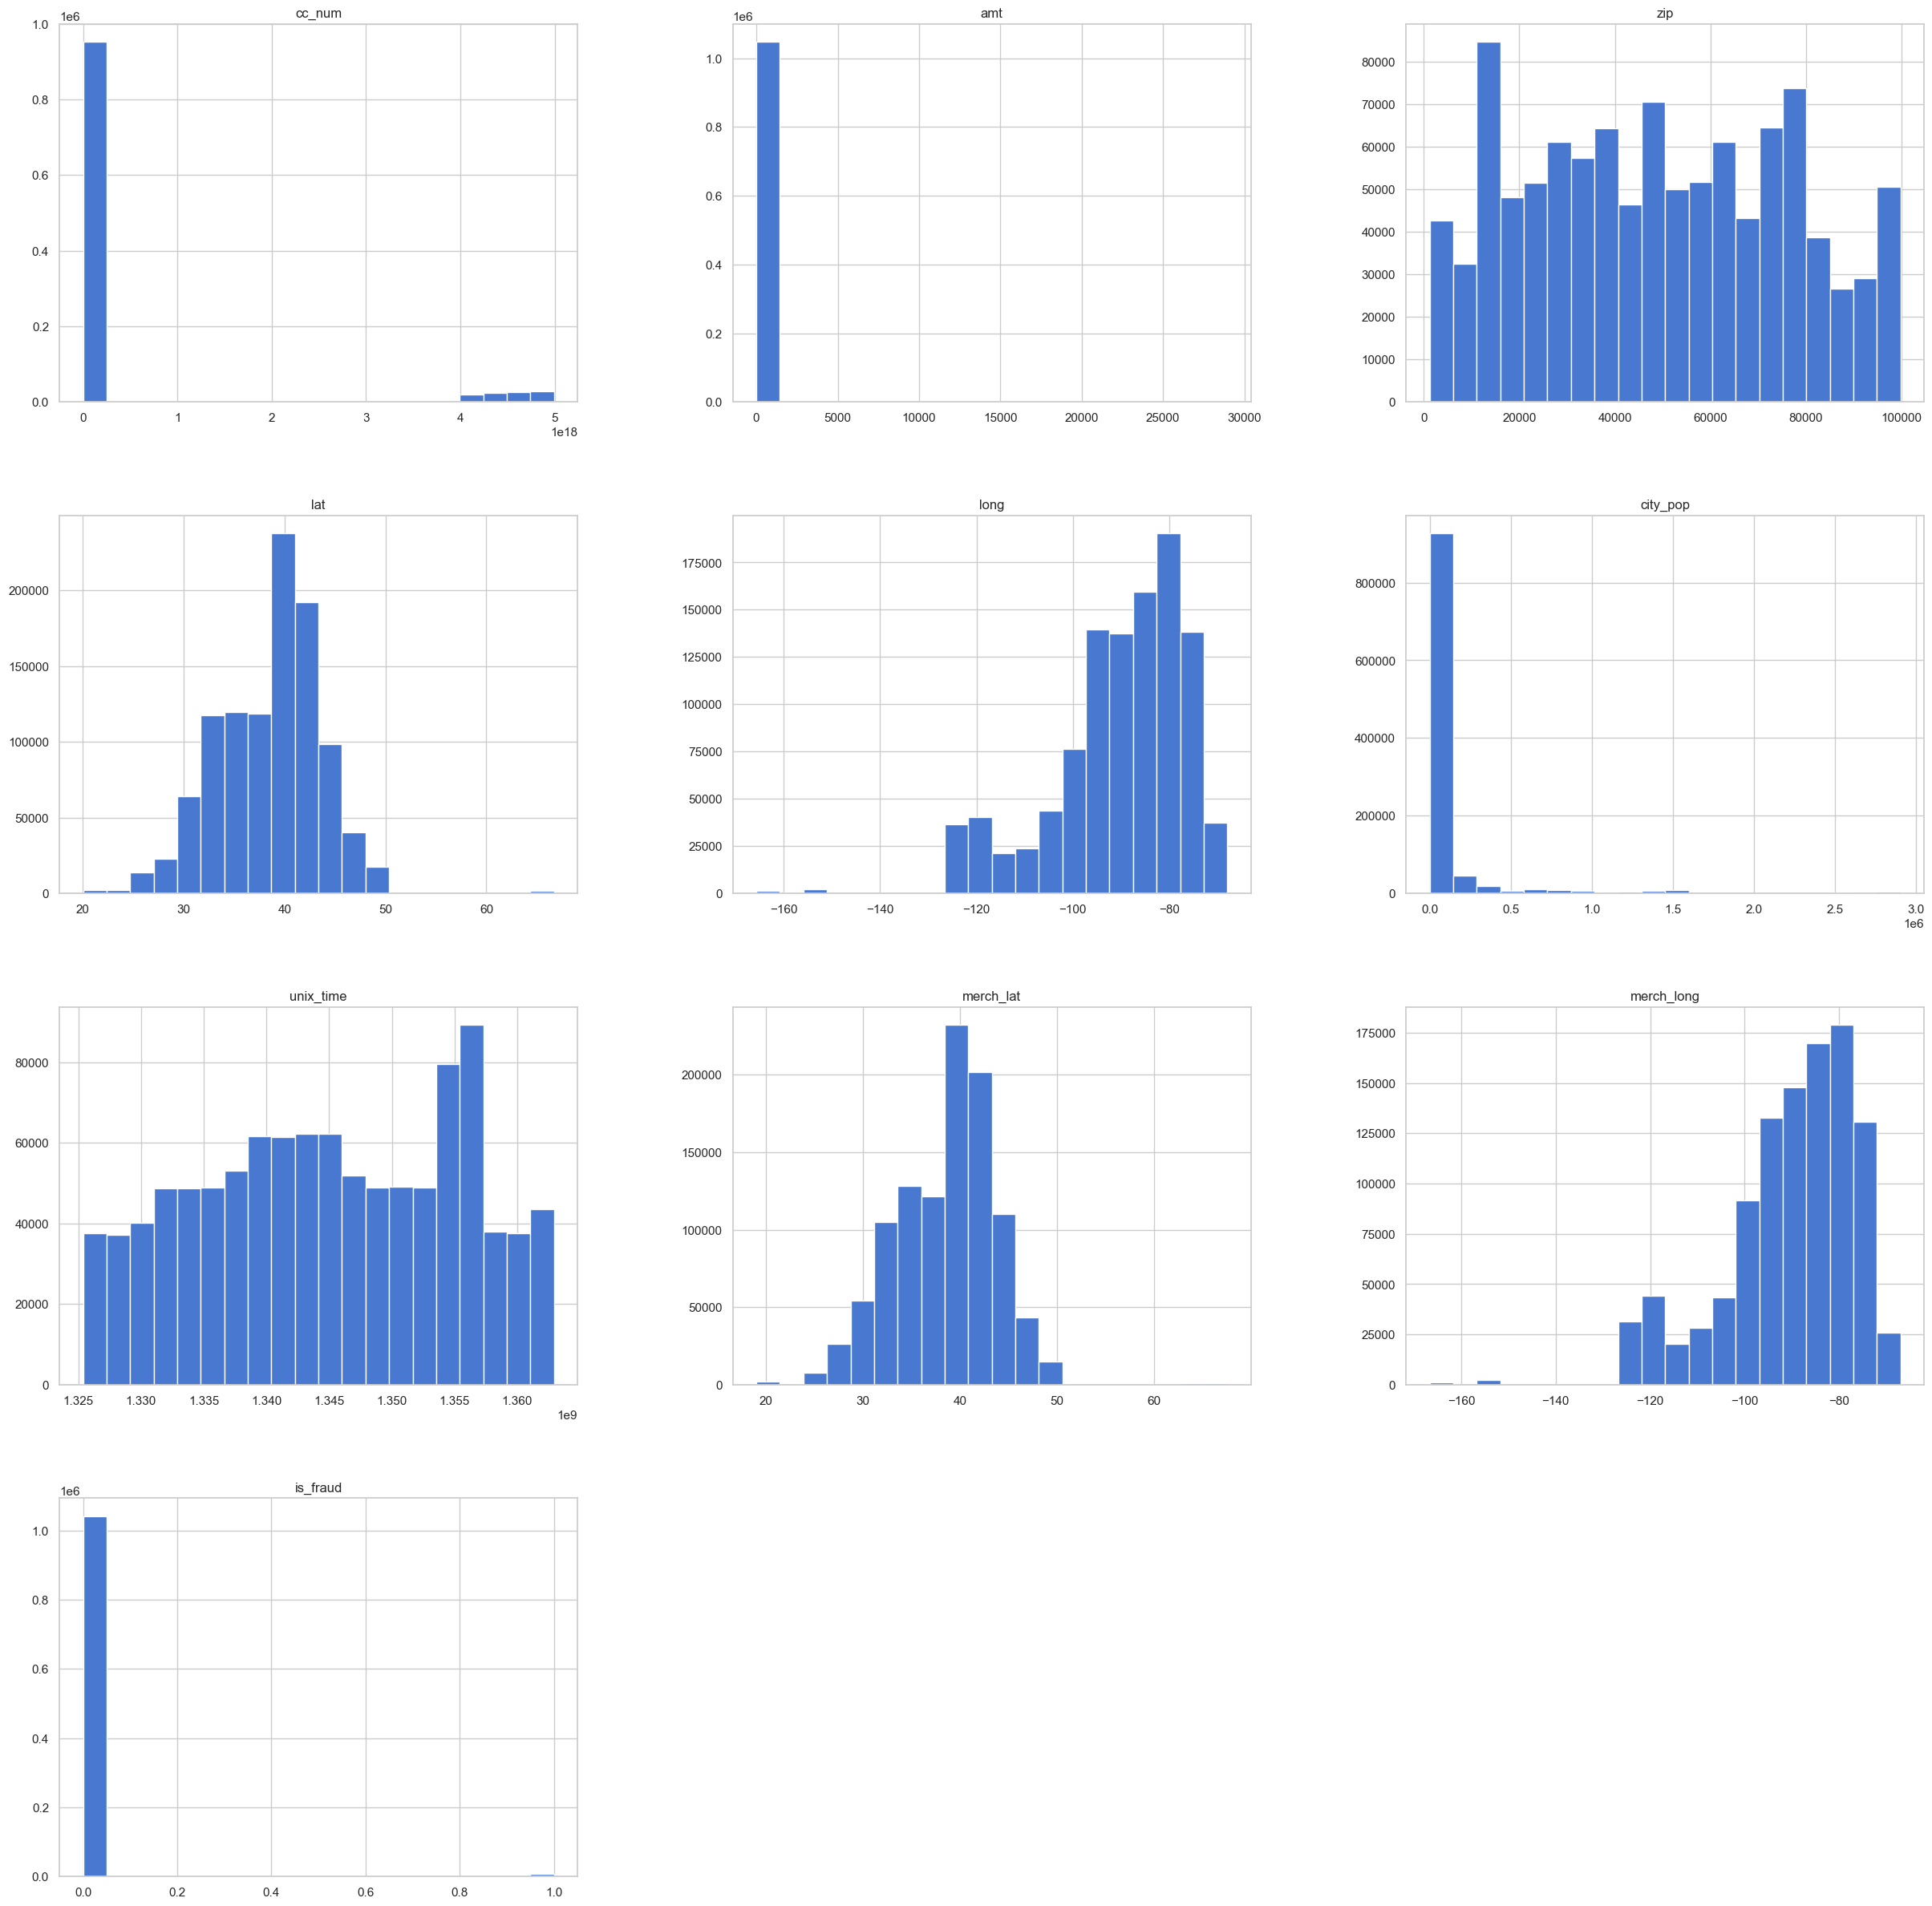

In [8]:
df.hist(bins=20, figsize=(30, 30))



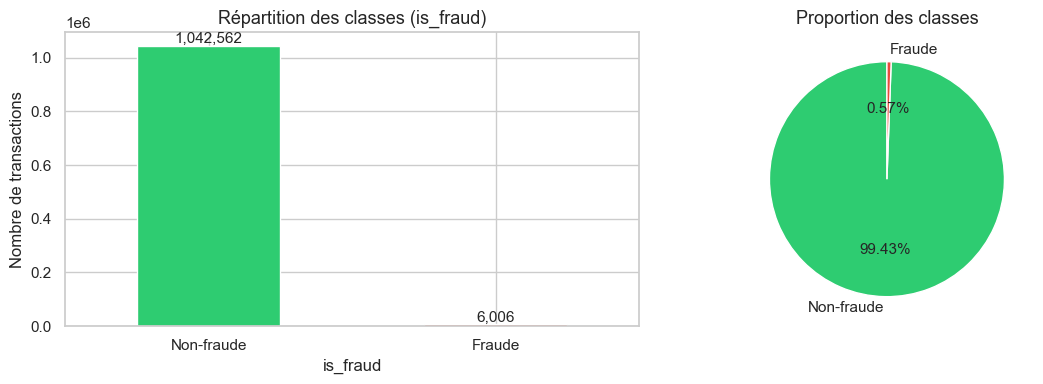

⚠ Fort déséquilibre → nécessite SMOTE ou class_weight lors de la modélisation


In [9]:
# --- Déséquilibre de classes ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
fraud_counts = df['is_fraud'].value_counts()
fraud_counts.plot(kind='bar', ax=axes[0], color=colors, rot=0)
axes[0].set_title('Répartition des classes (is_fraud)', fontsize=13)
axes[0].set_xticklabels(['Non-fraude', 'Fraude'])
axes[0].set_ylabel('Nombre de transactions')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():,.0f}', 
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Pie chart
axes[1].pie(fraud_counts, labels=['Non-fraude', 'Fraude'], colors=colors,
            autopct='%1.2f%%', startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proportion des classes', fontsize=13)

plt.tight_layout()
plt.show()
print('⚠ Fort déséquilibre → nécessite SMOTE ou class_weight lors de la modélisation')

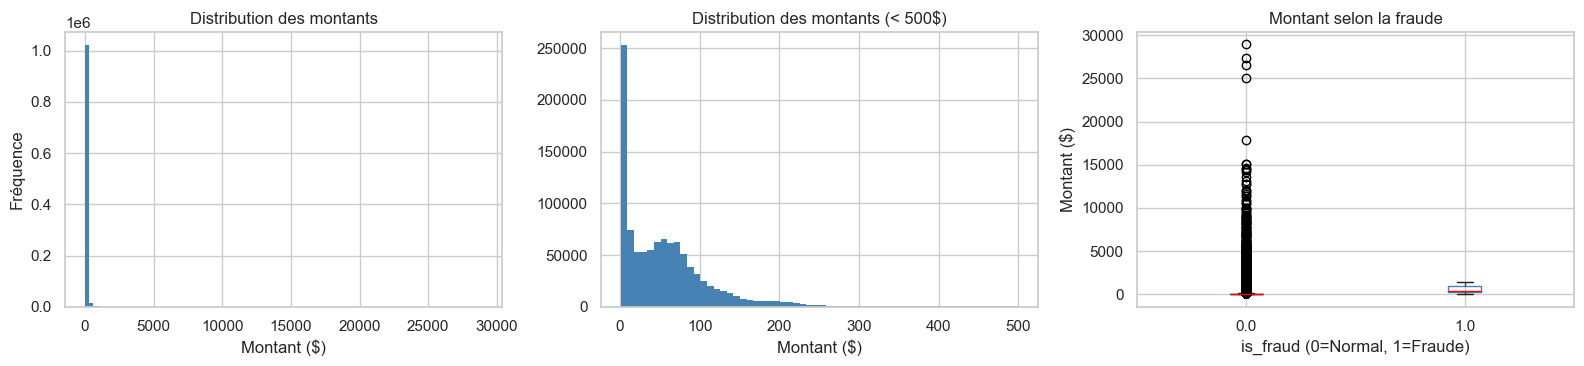

In [10]:
# --- Distribution du montant ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogramme global
axes[0].hist(df['amt'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Distribution des montants')
axes[0].set_xlabel('Montant ($)')
axes[0].set_ylabel('Fréquence')

# Montants < 500$
axes[1].hist(df[df['amt'] < 500]['amt'], bins=60, color='steelblue', edgecolor='none')
axes[1].set_title('Distribution des montants (< 500$)')
axes[1].set_xlabel('Montant ($)')

# Boxplot fraude vs non-fraude
df.boxplot(column='amt', by='is_fraud', ax=axes[2], 
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red'))
axes[2].set_title('Montant selon la fraude')
axes[2].set_xlabel('is_fraud (0=Normal, 1=Fraude)')
axes[2].set_ylabel('Montant ($)')
plt.suptitle('')  # retire le titre automatique

plt.tight_layout()
plt.show()

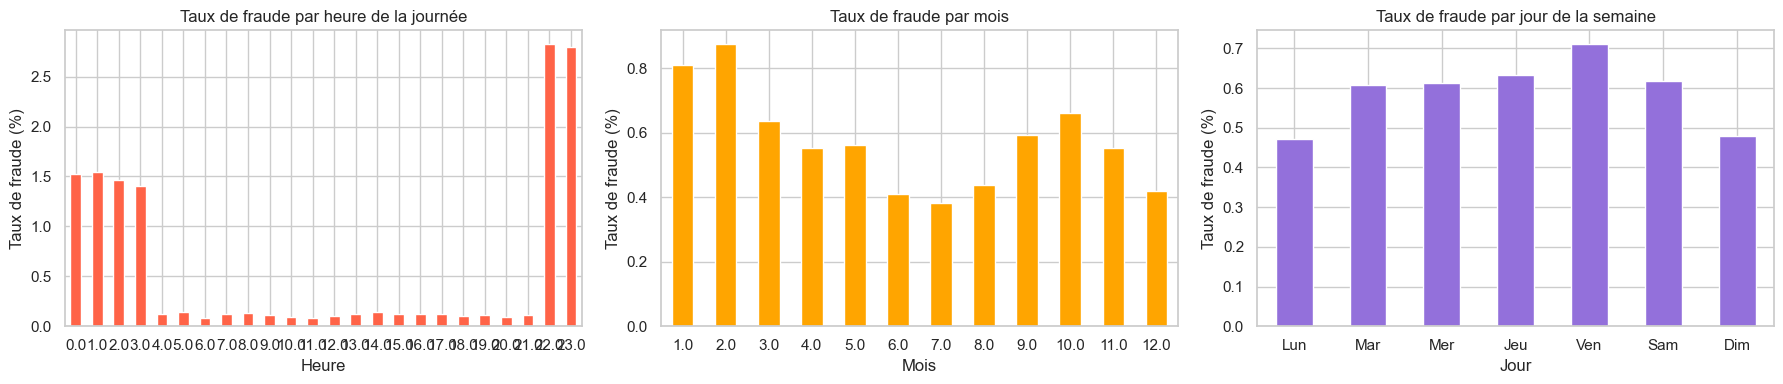

Observation : les fraudes sont plus fréquentes la nuit (22h-3h)


In [11]:
# --- Analyse temporelle ---
df_time = df.copy()
df_time['trans_date_trans_time'] = pd.to_datetime(df_time['trans_date_trans_time'])
df_time['trans_hour'] = df_time['trans_date_trans_time'].dt.hour
df_time['trans_month'] = df_time['trans_date_trans_time'].dt.month
df_time['trans_dayofweek'] = df_time['trans_date_trans_time'].dt.dayofweek

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Fraudes par heure
fraud_by_hour = df_time[df_time['is_fraud']==1]['trans_hour'].value_counts().sort_index()
total_by_hour = df_time['trans_hour'].value_counts().sort_index()
fraud_rate_hour = (fraud_by_hour / total_by_hour * 100).fillna(0)

fraud_rate_hour.plot(kind='bar', ax=axes[0], color='tomato', rot=0)
axes[0].set_title('Taux de fraude par heure de la journée')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('Taux de fraude (%)')

# Fraudes par mois
fraud_by_month = df_time[df_time['is_fraud']==1]['trans_month'].value_counts().sort_index()
total_by_month = df_time['trans_month'].value_counts().sort_index()
(fraud_by_month / total_by_month * 100).fillna(0).plot(kind='bar', ax=axes[1], color='orange', rot=0)
axes[1].set_title('Taux de fraude par mois')
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('Taux de fraude (%)')

# Fraudes par jour de semaine
jours = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
fraud_by_dow = df_time[df_time['is_fraud']==1]['trans_dayofweek'].value_counts().sort_index()
total_by_dow = df_time['trans_dayofweek'].value_counts().sort_index()
fraud_rate_dow = (fraud_by_dow / total_by_dow * 100).fillna(0)
fraud_rate_dow.index = jours
fraud_rate_dow.plot(kind='bar', ax=axes[2], color='mediumpurple', rot=0)
axes[2].set_title('Taux de fraude par jour de la semaine')
axes[2].set_xlabel('Jour')
axes[2].set_ylabel('Taux de fraude (%)')

plt.tight_layout()
plt.show()
print('Observation : les fraudes sont plus fréquentes la nuit (22h-3h)')

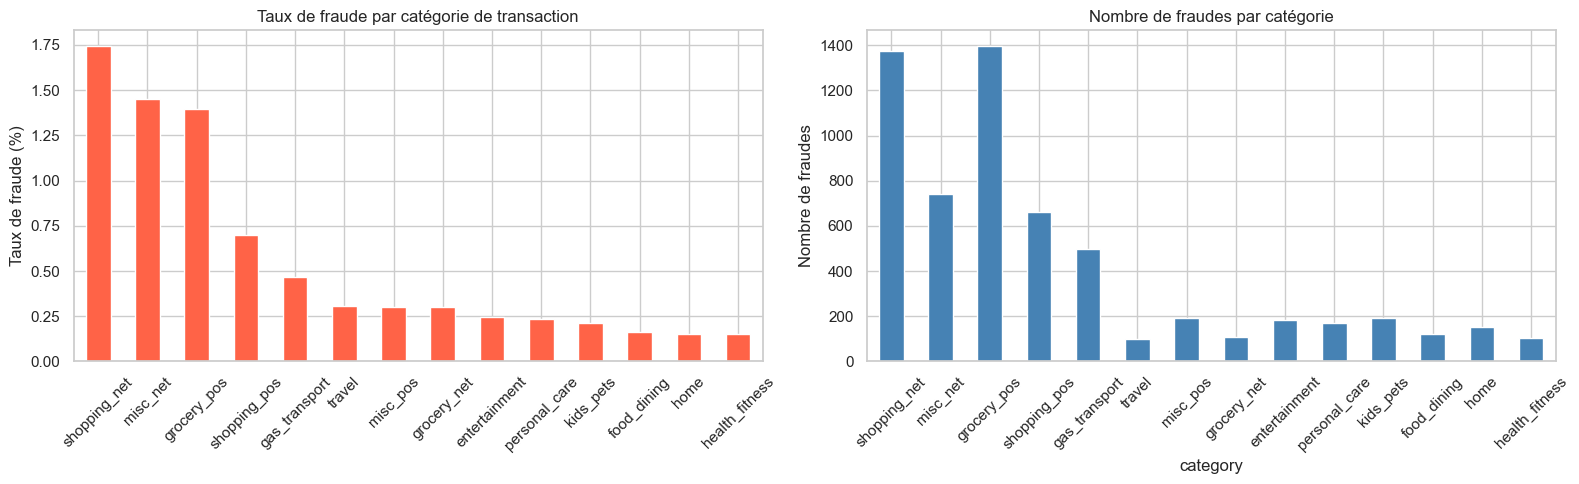

Catégories les plus risquées : ['shopping_net', 'misc_net', 'grocery_pos']


In [12]:
# --- Analyse par catégorie ---
cat_fraud = df.groupby('category')['is_fraud'].agg(['sum', 'count'])
cat_fraud['taux_fraude'] = cat_fraud['sum'] / cat_fraud['count'] * 100
cat_fraud = cat_fraud.sort_values('taux_fraude', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Taux de fraude par catégorie
cat_fraud['taux_fraude'].plot(kind='bar', ax=axes[0], color='tomato', rot=45)
axes[0].set_title('Taux de fraude par catégorie de transaction')
axes[0].set_ylabel('Taux de fraude (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', labelrotation=45)

# Volume de fraudes par catégorie
cat_fraud['sum'].plot(kind='bar', ax=axes[1], color='steelblue', rot=45)
axes[1].set_title('Nombre de fraudes par catégorie')
axes[1].set_ylabel('Nombre de fraudes')
axes[1].tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()
print('Catégories les plus risquées :', cat_fraud['taux_fraude'].head(3).index.tolist())

## 7. Analyse des corrélations

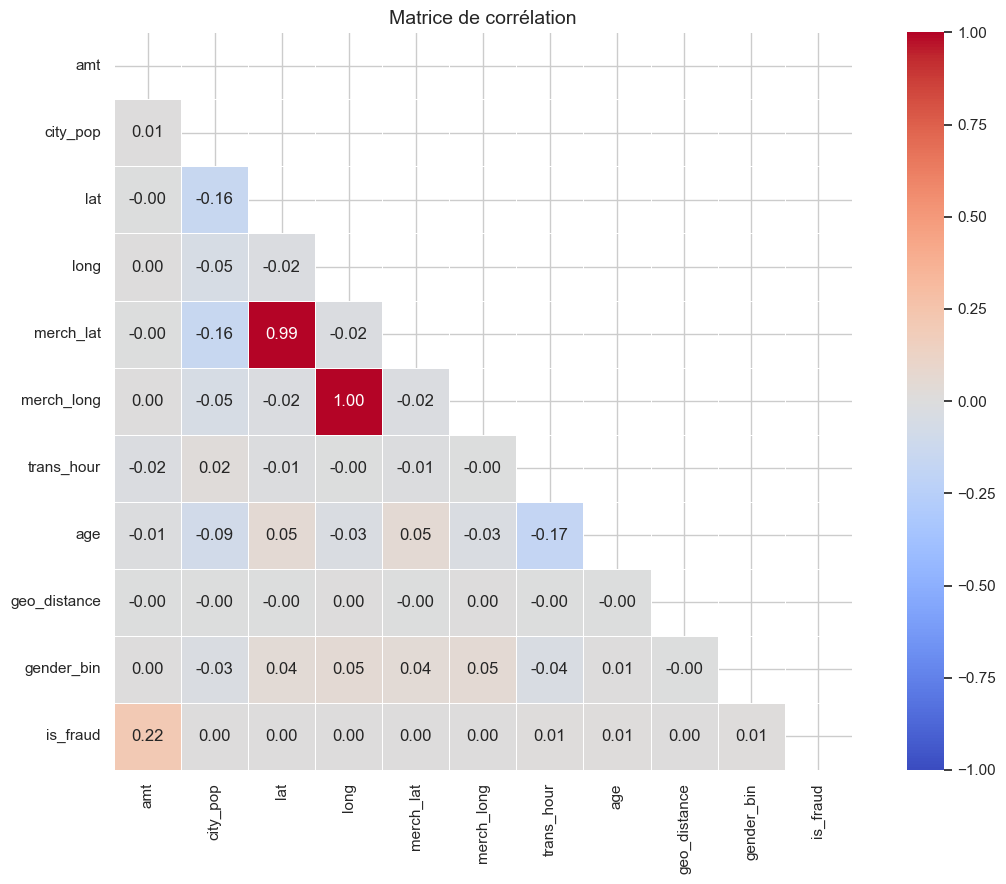

In [13]:
# Ajout des features temporelles pour la corrélation
df_corr = df.copy()
df_corr['trans_date_trans_time'] = pd.to_datetime(df_corr['trans_date_trans_time'])
df_corr['dob'] = pd.to_datetime(df_corr['dob'])
df_corr['trans_hour'] = df_corr['trans_date_trans_time'].dt.hour
df_corr['age'] = (df_corr['trans_date_trans_time'] - df_corr['dob']).dt.days // 365
df_corr['geo_distance'] = np.sqrt(
    (df_corr['lat'] - df_corr['merch_lat'])**2 + 
    (df_corr['long'] - df_corr['merch_long'])**2
)
df_corr['gender_bin'] = df_corr['gender'].map({'M': 1, 'F': 0})

# Sélection des colonnes numériques
cols_corr = ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long',
             'trans_hour', 'age', 'geo_distance', 'gender_bin', 'is_fraud']
corr_matrix = df_corr[cols_corr].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5
)
plt.title('Matrice de corrélation', fontsize=14)
plt.tight_layout()
plt.show()

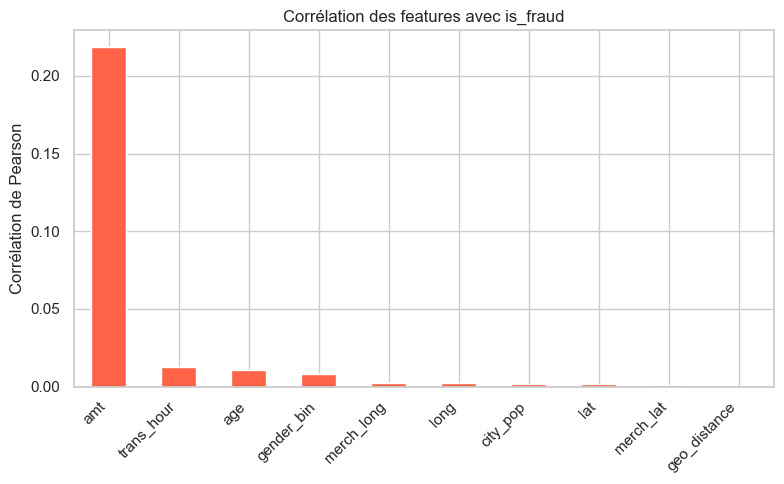

Top corrélations positives avec is_fraud :
amt           0.218417
trans_hour    0.012416
age           0.010723
gender_bin    0.007935
merch_long    0.002055
Name: is_fraud, dtype: float64

Top corrélations négatives :
Series([], Name: is_fraud, dtype: float64)


In [14]:
# Corrélations avec is_fraud (triées)
corr_with_target = corr_matrix['is_fraud'].drop('is_fraud').sort_values(key=abs, ascending=False)

plt.figure(figsize=(8, 5))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_with_target]
corr_with_target.plot(kind='bar', color=colors)
plt.title('Corrélation des features avec is_fraud')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.ylabel('Corrélation de Pearson')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top corrélations positives avec is_fraud :')
print(corr_with_target[corr_with_target > 0].head())
print('\nTop corrélations négatives :')
print(corr_with_target[corr_with_target < 0].head())

## 8. Détection des Outliers

In [15]:
# Méthode IQR sur la colonne amt
Q1 = df['amt'].quantile(0.25)
Q3 = df['amt'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_amt = df[(df['amt'] < lower) | (df['amt'] > upper)]
print(f'=== Outliers sur amt (méthode IQR) ===')
print(f'Borne inférieure : {lower:.2f}$')
print(f'Borne supérieure : {upper:.2f}$')
print(f'Nombre d\'outliers : {len(outliers_amt):,} ({len(outliers_amt)/len(df)*100:.2f}%)')
print(f'\nTaux de fraude dans les outliers : {outliers_amt["is_fraud"].mean()*100:.2f}%')
print(f'Taux de fraude global : {df["is_fraud"].mean()*100:.4f}%')




=== Outliers sur amt (méthode IQR) ===
Borne inférieure : -100.47$
Borne supérieure : 193.16$
Nombre d'outliers : 54,542 (5.20%)

Taux de fraude dans les outliers : 8.35%
Taux de fraude global : 0.5728%


## 9. Analyse des variables catégorielles

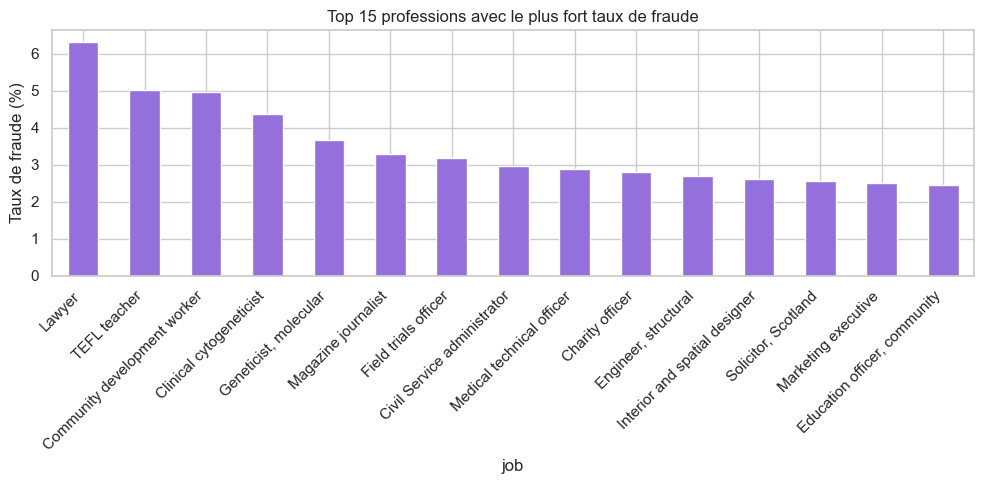

In [16]:
# Top 15 professions les plus frauduleuses
job_fraud = df.groupby('job')['is_fraud'].agg(['sum', 'count'])
job_fraud['taux'] = job_fraud['sum'] / job_fraud['count'] * 100
job_fraud = job_fraud[job_fraud['count'] >= 50]  # au moins 50 transactions
top_jobs = job_fraud.nlargest(15, 'taux')

plt.figure(figsize=(10, 5))
top_jobs['taux'].plot(kind='bar', color='mediumpurple')
plt.title('Top 15 professions avec le plus fort taux de fraude')
plt.ylabel('Taux de fraude (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. Hypothèses & Conclusions de l'EDA

### Observations clés :

1. Déséquilibre de classes : ~0.5% de fraudes — nécessite SMOTE ou `class_weight='balanced'` lors de la modélisation.

2. Temporalité : Les fraudes surviennent davantage la nuit (22h–3h) → `trans_hour` sera une feature importante.

3. Catégories risquées : `shopping_net`, `grocery_pos`, `misc_net` présentent les taux de fraude les plus élevés.

4. Montant : Les fraudes ne sont pas systématiquement sur des montants élevés — les fraudeurs imitent des transactions normales.

5. Distance géographique : Les transactions frauduleuses tendent à avoir une plus grande distance entre client et marchand → feature `geo_distance` pertinente.

6. Corrélations faibles : Pas de feature fortement corrélée à `is_fraud` → un modèle non-linéaire (Random Forest) sera plus adapté qu'une régression logistique.

### Features à construire pour le preprocessing :
- `trans_hour`, `trans_day`, `trans_month` (depuis `trans_date_trans_time`)
- `age` (depuis `dob`)
- `geo_distance` (depuis lat/long)

### Colonnes à supprimer (identifiants non prédictifs) :
`cc_num`, `first`, `last`, `street`, `city`, `state`, `zip`, `trans_num`, `merchant`

## 11. Suppression des colonnes non pertinentes

Justification : Les colonnes identifiantes (nom, prénom, adresse, numéro de carte, numéro de transaction, marchand) sont uniques par transaction et ne portent aucun signal prédictif généralisable. Les conserver provoquerait du surapprentissage.

In [17]:
cols_to_drop = [
    'cc_num',       # identifiant carte → pas généralisable
    'first',        # prénom → information personnelle
    'last',         # nom de famille
    'street',       # adresse précise
    'city',         # ville (trop de modalités)
    'state',        # état (remplacé par lat/long)
    'zip',          # code postal
    'trans_num',    # identifiant unique de transaction
    'merchant',     # trop de modalités (> 600 marchands)
]

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(f'Colonnes restantes')
print(df.columns.tolist())

Colonnes restantes
['trans_date_trans_time', 'category', 'amt', 'gender', 'lat', 'long', 'city_pop', 'job', 'dob', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']


## 12. Gestion des valeurs manquantes et dupliquer

Justification : On impute les valeurs manquantes numériques avec la médiane (robuste aux outliers) et les valeurs texte avec 'Unknown' pour ne pas perdre de lignes.

In [18]:
print('=== Valeurs manquantes avant traitement ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Aucune valeur manquante')
df.dropna(subset=['is_fraud']) 
df['is_fraud'].fillna(0).astype(int)  

# Imputation numérique : médiane
for col in ['lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'amt']:
    if col in df.columns:
        df[col].fillna(df[col].median(), inplace=True)

# Imputation textuelle
if 'job' in df.columns:
    df['job'].fillna('Unknown', inplace=True)
if 'gender' in df.columns:
    df['gender'].fillna(df['gender'].mode()[0], inplace=True)

print(f'\nValeurs manquantes après traitement : {df.isnull().sum().sum()}')

=== Valeurs manquantes avant traitement ===
trans_date_trans_time    2
job                      1
dob                      2
unix_time                1
merch_lat                1
merch_long               1
is_fraud                 1
dtype: int64


C:\Users\arnau\AppData\Local\Temp\ipykernel_6816\3631273398.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\arnau\AppData\Local\Temp\ipykernel_6816\3631273398.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp


Valeurs manquantes après traitement : 6


C:\Users\arnau\AppData\Local\Temp\ipykernel_6816\3631273398.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].fillna(df['gender'].mode()[0], inplace=True)


## 13. Feature Engineering

Justification : L'EDA a montré que l'heure de la transaction et la distance client-marchand sont des indicateurs pertinents. On les crée à partir des colonnes brutes.

In [21]:
# Parsing des dates
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

# Features temporelles
df['trans_hour']  = df['trans_date_trans_time'].dt.hour          # heure de la transaction
df['trans_day']   = df['trans_date_trans_time'].dt.dayofweek     # jour de la semaine (0=lundi)
df['trans_month'] = df['trans_date_trans_time'].dt.month         # mois

# Âge du client au moment de la transaction
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# Distance géographique entre client et marchand (approximation euclidienne sur degrés)
df['geo_distance'] = np.sqrt(
    (df['lat'] - df['merch_lat'])**2 + (df['long'] - df['merch_long'])**2
)

# Suppression des colonnes dates brutes (information extraite)
df.drop(columns=['trans_date_trans_time', 'dob', 'unix_time'], inplace=True, errors='ignore')

print('Nouvelles features créées :')
print('trans_hour, trans_day, trans_month, age, geo_distance')
display(df[['trans_hour', 'trans_day', 'trans_month', 'age', 'geo_distance', 'is_fraud']].head(3))

Nouvelles features créées :
trans_hour, trans_day, trans_month, age, geo_distance


,trans_hour,trans_day,trans_month,age,geo_distance,is_fraud
0,0.0,1.0,1.0,30.0,0.872830,0.0
1,0.0,1.0,1.0,40.0,0.272310,0.0
2,0.0,1.0,1.0,56.0,0.975845,0.0


## 14. Encodage des variables catégorielles

Justification :
- `gender` : 2 modalités → encodage binaire (M=1, F=0), simple et suffisant.
- `category` : 14 modalités → `LabelEncoder` (one-hot ajouterait trop de colonnes peu denses).
- `job` : 400+ modalités → `LabelEncoder` obligatoire (one-hot créerait 400+ colonnes).

In [22]:
# Genre → binaire
df['gender'] = df['gender'].map({'M': 1, 'F': 0})
print('gender encodé en binaire (M=1, F=0)')

# Catégorie de transaction → LabelEncoder
le_category = LabelEncoder()
df['category'] = le_category.fit_transform(df['category'].astype(str))
print(f'category encodé ({len(le_category.classes_)} classes) : {le_category.classes_.tolist()}')

# Profession → LabelEncoder
le_job = LabelEncoder()
df['job'] = le_job.fit_transform(df['job'].astype(str))
print(f'job encodé ({len(le_job.classes_)} classes)')

print(f'\nTypes après encodage :')
print(df.dtypes)

gender encodé en binaire (M=1, F=0)
category encodé (14 classes) : ['entertainment', 'food_dining', 'gas_transport', 'grocery_net', 'grocery_pos', 'health_fitness', 'home', 'kids_pets', 'misc_net', 'misc_pos', 'personal_care', 'shopping_net', 'shopping_pos', 'travel']
job encodé (494 classes)

Types après encodage :
category          int64
amt             float64
gender            int64
lat             float64
long            float64
city_pop          int64
job               int64
merch_lat       float64
merch_long      float64
is_fraud        float64
trans_hour      float64
trans_day       float64
trans_month     float64
age             float64
geo_distance    float64
dtype: object


## 15. Séparation Features / Cible & Train/Test Split

In [23]:
df = df.dropna(subset=['is_fraud'])   # supprime les lignes avec NaN dans is_fraud
y = df['is_fraud'].fillna(0).astype(int)  # double sécurité

X = df.drop(columns=['is_fraud'])
y = df['is_fraud'].astype(int)

df = df.dropna(subset=['is_fraud'])   # supprime les lignes avec NaN dans is_fraud
y = df['is_fraud'].fillna(0).astype(int)  # double sécurité

print(f'Features : {X.shape[1]} colonnes')
print(f'Features utilisées : {X.columns.tolist()}')
print(f'\nRépartition de la cible :')
print(y.value_counts().to_frame().assign(pct=lambda d: (d['count']/len(y)*100).round(4)))

# Split stratifié pour conserver le ratio fraude/non-fraude dans les deux sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nSplit effectué :')
print(f'  Train : {X_train.shape[0]:,} ({y_train.mean()*100:.4f}% fraudes)')
print(f'  Test  : {X_test.shape[0]:,}  ({y_test.mean()*100:.4f}% fraudes)')

Features : 14 colonnes
Features utilisées : ['category', 'amt', 'gender', 'lat', 'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'trans_hour', 'trans_day', 'trans_month', 'age', 'geo_distance']

Répartition de la cible :
            count      pct
is_fraud                  
0         1042562  99.4272
1            6006   0.5728

Split effectué :
  Train : 838,854 (0.5728% fraudes)
  Test  : 209,714  (0.5727% fraudes)


## 16. Normalisation (StandardScaler)

Justification : Le `StandardScaler` centre et réduit les variables (moyenne=0, écart-type=1). Il est appliqué après le split pour éviter toute fuite de données (*data leakage*) : le scaler est fitté uniquement sur le train, puis appliqué au test.

In [24]:
scaler = StandardScaler()

# Fit sur le train UNIQUEMENT, transform sur les deux
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print('Statistiques du train après normalisation :')
display(X_train_scaled.describe().round(3))

Statistiques du train après normalisation :


,category,amt,gender,lat,long,city_pop,job,merch_lat,merch_long,trans_hour,trans_day,trans_month,age,geo_distance
count,838854.000,838854.000,838854.000,838854.000,838854.000,838854.000,838854.000,838854.000,838854.000,838853.000,838853.000,838853.000,838851.000,838854.000
mean,-0.000,0.000,0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.592,-0.424,-0.910,-3.647,-5.484,-0.294,-1.792,-3.818,-5.551,-1.879,-1.424,-1.504,-1.864,-2.687
25%,-0.825,-0.371,-0.910,-0.771,-0.478,-0.292,-0.858,-0.744,-0.485,-0.852,-0.970,-0.958,-0.772,-0.705
50%,-0.059,-0.140,-0.910,0.162,0.200,-0.286,-0.001,0.162,0.202,0.175,-0.061,0.133,-0.139,0.114
75%,0.964,0.077,1.099,0.671,0.732,-0.227,0.876,0.670,0.726,0.909,0.848,0.951,0.666,0.745
max,1.730,176.496,1.099,5.549,1.619,9.318,1.726,5.672,1.690,1.496,1.302,1.496,2.851,9.994


## 17. Gestion du déséquilibre de classes (SMOTE)

Justification : Avec ~0.5% de fraudes, un modèle naïf prédirait toujours 0 et aurait 99.5% d'accuracy mais serait inutile. SMOTE (*Synthetic Minority Oversampling Technique*) génère des exemples synthétiques de la classe minoritaire en interpolant entre les points existants.  
Important : SMOTE est appliqué uniquement sur le train pour ne pas contaminer le test set.

In [27]:
# Vérification et suppression des NaN restants
print(f'NaN dans X_train_scaled : {X_train_scaled.isna().sum().sum()}')
print(f'NaN dans X_test_scaled  : {X_test_scaled.isna().sum().sum()}')

# Imputation des NaN restants avec la médiane de chaque colonne
X_train_scaled = X_train_scaled.fillna(X_train_scaled.median())
X_test_scaled  = X_test_scaled.fillna(X_test_scaled.median())

# Vérification
print(f'\nAprès correction :')
print(f'NaN dans X_train_scaled : {X_train_scaled.isna().sum().sum()}')
print(f'NaN dans X_test_scaled  : {X_test_scaled.isna().sum().sum()}')

NaN dans X_train_scaled : 0
NaN dans X_test_scaled  : 0

Après correction :
NaN dans X_train_scaled : 0
NaN dans X_test_scaled  : 0


Avant SMOTE — Train : {0: 834049, 1: 4805}
  Taux de fraude : 0.5728%

Après SMOTE — Train : {0: 834049, 1: 250214}
  Taux de fraude : 23.08%


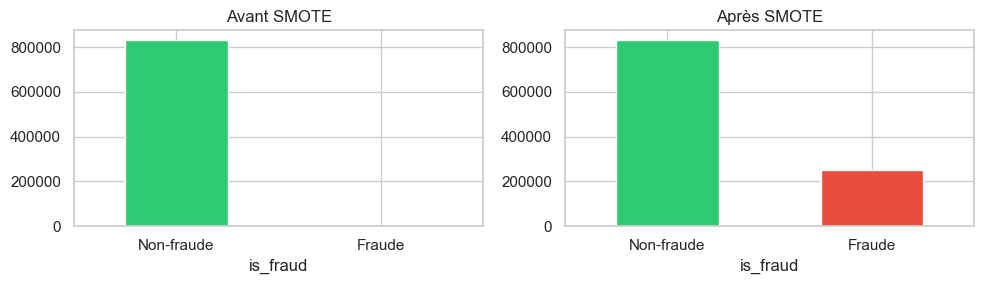

SMOTE appliqué — données rééquilibrées pour la modélisation


In [28]:
print(f'Avant SMOTE — Train : {y_train.value_counts().to_dict()}')
print(f'  Taux de fraude : {y_train.mean()*100:.4f}%')

# SMOTE avec sampling_strategy=0.3 : ratio fraude/non-fraude = 30%
smote = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f'\nAprès SMOTE — Train : {pd.Series(y_train_res).value_counts().to_dict()}')
print(f'  Taux de fraude : {y_train_res.mean()*100:.2f}%')

# Visualisation avant/après
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
colors = ['#2ecc71', '#e74c3c']

pd.Series(y_train).value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=colors, rot=0
)
axes[0].set_title('Avant SMOTE')
axes[0].set_xticklabels(['Non-fraude', 'Fraude'])

pd.Series(y_train_res).value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=colors, rot=0
)
axes[1].set_title('Après SMOTE')
axes[1].set_xticklabels(['Non-fraude', 'Fraude'])

plt.tight_layout()
plt.show()
print('SMOTE appliqué — données rééquilibrées pour la modélisation')

## 18. Résumé du Preprocessing

| Étape | Action | Justification |
|---|---|---|
| Suppression de colonnes | 9 colonnes identifiantes supprimées | Pas de signal prédictif, risque de surapprentissage |
| Valeurs manquantes | Imputation médiane (numérique), 'Unknown' (texte) | Robuste aux outliers, pas de perte de lignes |
| Feature Engineering | 5 nouvelles features créées | Capture la temporalité et la géographie (signaux détectés en EDA) |
| Encodage | Binaire (gender), LabelEncoder (category, job) | Adapté à la cardinalité de chaque variable |
| Train/Test split | 80/20 stratifié | Conserve le ratio fraude dans les deux sets |
| Normalisation | StandardScaler (fit sur train seulement) | Évite le data leakage, nécessaire pour clustering et régression logistique |
| SMOTE | sampling_strategy=0.3 sur train uniquement | Rééquilibre la classe minoritaire sans contaminer le test |

Données prêtes pour la modélisation :
- `X_train_res`, `y_train_res` → entraînement des modèles (avec SMOTE)
- `X_test_scaled`, `y_test` → évaluation finale (données réelles, non rééchantillonnées)

In [29]:
print('=== Récapitulatif final ===')
print(f'X_train_res : {X_train_res.shape}  — y_train_res : {y_train_res.shape}')
print(f'X_test_scaled : {X_test_scaled.shape} — y_test : {y_test.shape}')
print(f'\nFeatures ({X_train_res.shape[1]}) : {list(X_train_res.columns)}')

=== Récapitulatif final ===
X_train_res : (1084263, 14)  — y_train_res : (1084263,)
X_test_scaled : (209714, 14) — y_test : (209714,)

Features (14) : ['category', 'amt', 'gender', 'lat', 'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'trans_hour', 'trans_day', 'trans_month', 'age', 'geo_distance']


## 19. Modèle Supervisé — Random Forest

Justification : Le Random Forest est robuste aux données déséquilibrées, gère bien les features hétérogènes et fournit une importance des features. Il ne nécessite pas de distribution particulière des données.

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay

# Entraînement
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_res, y_train_res)

# Prédictions
y_pred  = rf.predict(X_test_scaled)
y_proba = rf.predict_proba(X_test_scaled)[:, 1]

print("=== Classification Report — Random Forest ===")
print(classification_report(y_test, y_pred, target_names=["Non-fraude", "Fraude"]))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba):.4f}")

=== Classification Report — Random Forest ===
              precision    recall  f1-score   support

  Non-fraude       1.00      0.99      1.00    208513
      Fraude       0.49      0.87      0.63      1201

    accuracy                           0.99    209714
   macro avg       0.75      0.93      0.81    209714
weighted avg       1.00      0.99      0.99    209714

AUC-ROC : 0.9927


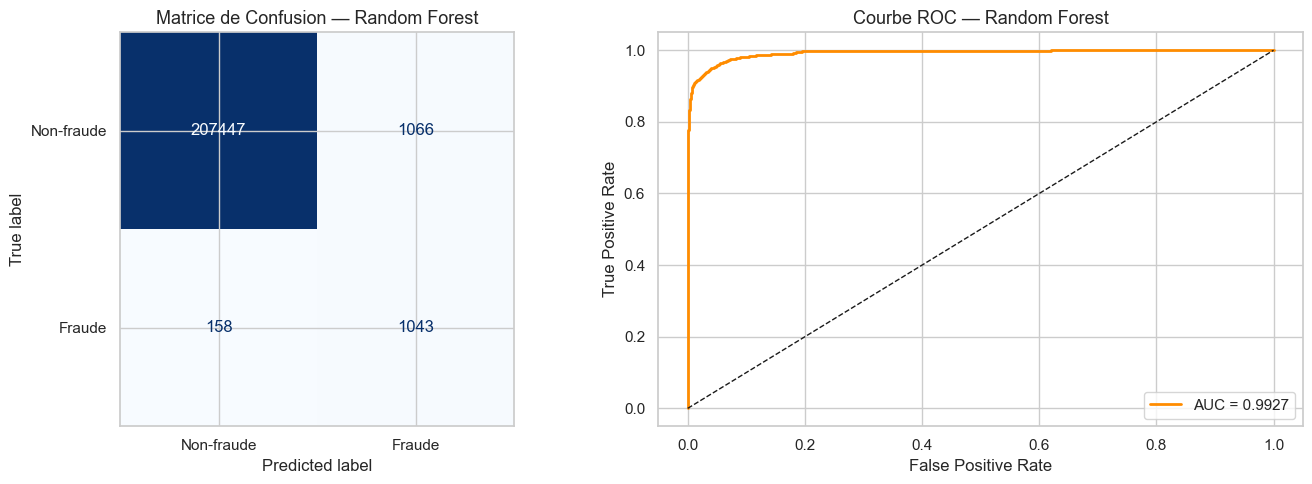

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Non-fraude", "Fraude"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matrice de Confusion — Random Forest", fontsize=13)

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {auc:.4f}", color="darkorange", lw=2)
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Courbe ROC — Random Forest", fontsize=13)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

## Métriques d'évaluation du modèle

### Matrice de confusion
Tableau 2×2 qui compare les prédictions du modèle aux valeurs réelles.
Elle permet de visualiser les vrais positifs (fraudes bien détectées),
les vrais négatifs (transactions normales bien classées),
les faux positifs (fausses alertes) et les faux négatifs (fraudes manquées).
C'est la métrique clé pour évaluer le coût réel des erreurs dans un contexte de détection de fraude.

### Courbe ROC & AUC
La courbe ROC (*Receiver Operating Characteristic*) illustre le compromis entre
le taux de vrais positifs (recall) et le taux de faux positifs pour tous les seuils de décision possibles.
L'AUC (Area Under the Curve) résume cette courbe en un score entre 0 et 1 :
plus il est proche de 1, plus le modèle discrimine efficacement les fraudes des transactions légitimes.
Un AUC > 0.97 indique une excellente capacité de détection.

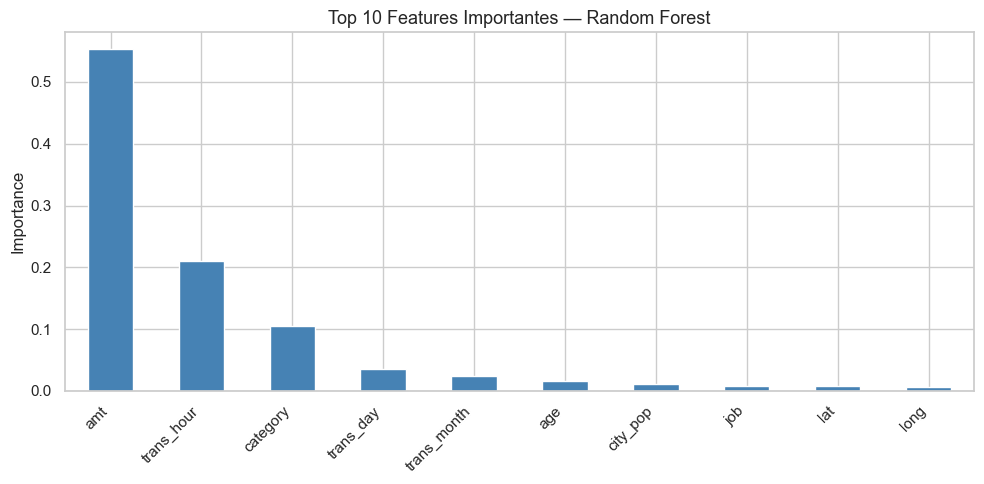

Top 5 features : ['amt', 'trans_hour', 'category', 'trans_day', 'trans_month']


In [32]:
# Importance des features
feat_imp = pd.Series(rf.feature_importances_, index=X_train_res.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.head(10).plot(kind="bar", color="steelblue")
plt.title("Top 10 Features Importantes — Random Forest", fontsize=13)
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Top 5 features :", feat_imp.head(5).index.tolist())

## 20. Modèle Non Supervisé — K-Means Clustering

Justification : Le clustering permet de regrouper les transactions par comportement similaire, sans utiliser les étiquettes. On applique une réduction PCA à 2 dimensions pour la visualisation, et on détermine le nombre de clusters optimal via la méthode du coude.

 On travaille sur un échantillon de 20 000 transactions pour des raisons de performance.

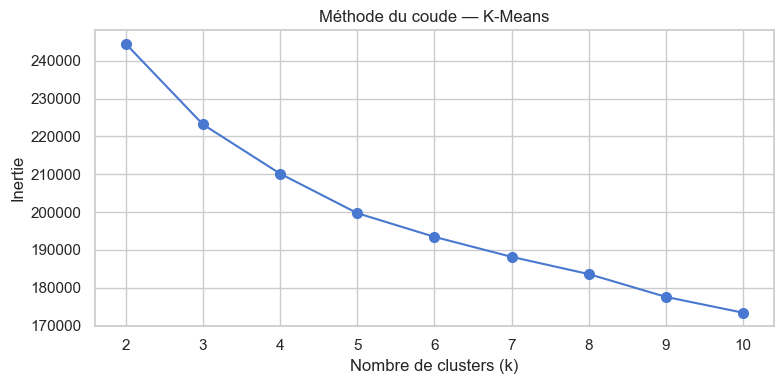

On choisit k=4 (coude visible sur le graphe)


In [33]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Échantillon pour la rapidité
sample_size = 20000
X_sample = X_train_scaled.sample(n=sample_size, random_state=42)
y_sample = y_train.loc[X_sample.index]

# Méthode du coude
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sample)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, "bo-", markersize=7)
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du coude — K-Means")
plt.xticks(K_range)
plt.tight_layout()
plt.show()
print("On choisit k=4 (coude visible sur le graphe)")

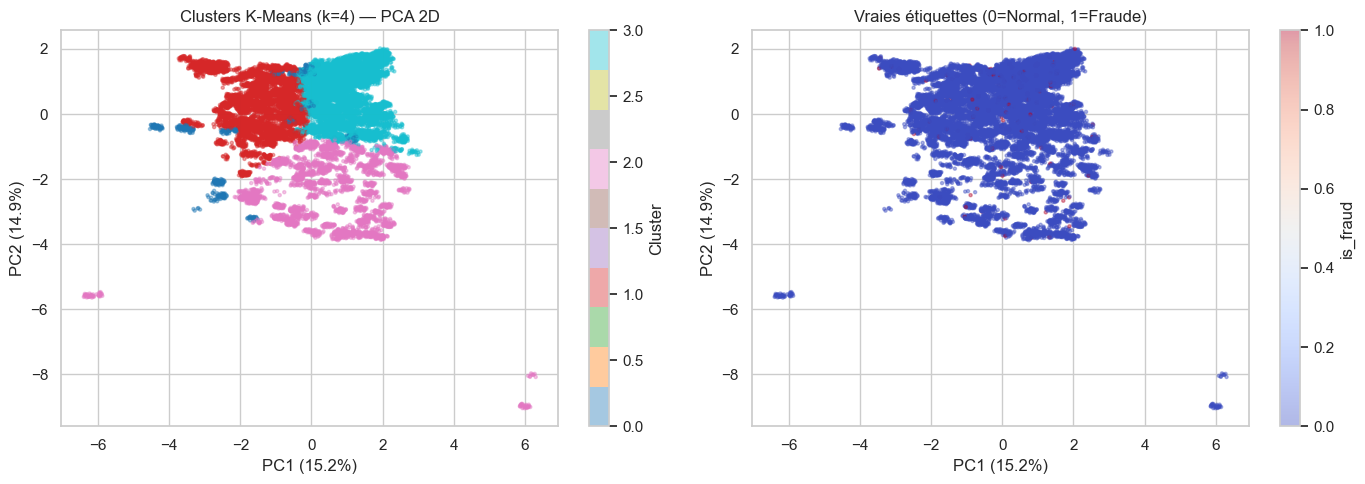

In [34]:
# K-Means avec k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_sample)

# Réduction PCA pour visualisation 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clusters trouvés
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters,
                           cmap="tab10", alpha=0.4, s=5)
axes[0].set_title("Clusters K-Means (k=4) — PCA 2D")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(scatter1, ax=axes[0], label="Cluster")

# Vraies étiquettes (fraude)
scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample.values,
                           cmap="coolwarm", alpha=0.4, s=5)
axes[1].set_title("Vraies étiquettes (0=Normal, 1=Fraude)")
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(scatter2, ax=axes[1], label="is_fraud")

plt.tight_layout()
plt.show()

=== Taux de fraude par cluster ===


,nb_fraudes,nb_total,taux_fraude
cluster,,,
0,4,607,0.659
1,34,6243,0.545
2,22,3559,0.618
3,65,9591,0.678


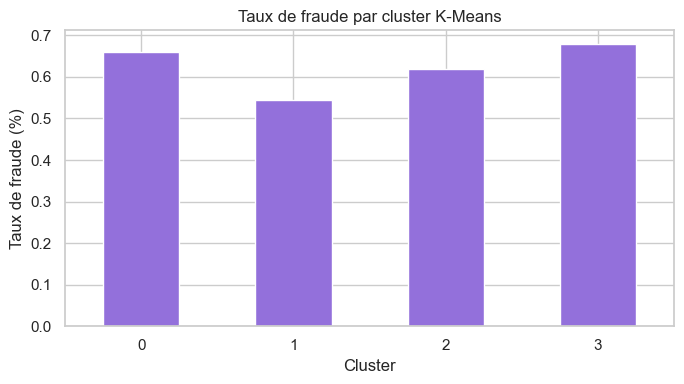

Les clusters avec un taux de fraude élevé correspondent aux comportements suspects identifiés en EDA


In [35]:
# Taux de fraude par cluster
cluster_df = pd.DataFrame({
    "cluster": clusters,
    "is_fraud": y_sample.values
})

analyse = cluster_df.groupby("cluster")["is_fraud"].agg(
    nb_fraudes="sum",
    nb_total="count"
).assign(taux_fraude=lambda d: (d["nb_fraudes"] / d["nb_total"] * 100).round(3))

print("=== Taux de fraude par cluster ===")
display(analyse)

# Visualisation
plt.figure(figsize=(7, 4))
analyse["taux_fraude"].plot(kind="bar", color="mediumpurple", rot=0)
plt.title("Taux de fraude par cluster K-Means")
plt.xlabel("Cluster")
plt.ylabel("Taux de fraude (%)")
plt.tight_layout()
plt.show()

print("Les clusters avec un taux de fraude élevé correspondent aux comportements suspects identifiés en EDA")

In [36]:
print('=== Récapitulatif final ===')
print(f'X_train_res : {X_train_res.shape}  — y_train_res : {y_train_res.shape}')
print(f'X_test_scaled : {X_test_scaled.shape} — y_test : {y_test.shape}')
print(f'\nFeatures ({X_train_res.shape[1]}) : {list(X_train_res.columns)}')

=== Récapitulatif final ===
X_train_res : (1084263, 14)  — y_train_res : (1084263,)
X_test_scaled : (209714, 14) — y_test : (209714,)

Features (14) : ['category', 'amt', 'gender', 'lat', 'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'trans_hour', 'trans_day', 'trans_month', 'age', 'geo_distance']


## 21. Sauvegarde du modèle (.pkl)

On sauvegarde le pipeline complet — modèle, scaler et encodeurs — dans un fichier `model.pkl`
afin de pouvoir recharger et réutiliser exactement les mêmes transformations lors des prédictions via l'API,
sans avoir à réentraîner le modèle.

Le fichier contient :
- `model` : le Random Forest entraîné
- `scaler` : le StandardScaler fitté sur le train
- `label_encoder_category` : l'encodeur de la colonne `category`
- `label_encoder_job` : l'encodeur de la colonne `job`
- `feature_names` : la liste des features dans le bon ordre

Une vérification de rechargement est effectuée immédiatement après la sauvegarde
pour confirmer que le fichier est lisible et que le modèle produit bien des prédictions.

In [37]:
import pickle
import os

# Chemin relatif vers le dossier api
save_path = os.path.join(os.getcwd(), "api")

# Créer le dossier s'il n'existe pas
os.makedirs(save_path, exist_ok=True)

# Sauvegarde du pipeline complet
model_pipeline = {
    "model"                  : rf,
    "scaler"                 : scaler,
    "label_encoder_category" : le_category,
    "label_encoder_job"      : le_job,
    "feature_names"          : X_train_res.columns.tolist()
}
    
with open(os.path.join(save_path, "model.pkl"), "wb") as f:
    pickle.dump(model_pipeline, f)

In [38]:
import pickle
import os

save_path = os.path.join(os.getcwd(), "api", "model.pkl")
with open(save_path, "rb") as f:
    loaded = pickle.load(f)

print("Clés dans le pipeline :", list(loaded.keys()))
print("Features attendues :", loaded['feature_names'])

test_pred  = loaded['model'].predict(X_test_scaled[:5])
test_proba = loaded['model'].predict_proba(X_test_scaled[:5])[:, 1]

print("Prédictions  :", test_pred)
print("Probabilités :", test_proba.round(4))

Clés dans le pipeline : ['model', 'scaler', 'label_encoder_category', 'label_encoder_job', 'feature_names']
Features attendues : ['category', 'amt', 'gender', 'lat', 'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'trans_hour', 'trans_day', 'trans_month', 'age', 'geo_distance']
Prédictions  : [0 0 0 0 0]
Probabilités : [0.0313 0.0215 0.006  0.0269 0.0163]


In [39]:
import pickle
import os

save_path = os.path.join(os.getcwd(), "api", "model.pkl")
with open(save_path, "rb") as f:
    loaded = pickle.load(f)

print("Clés dans le pipeline :", list(loaded.keys()))
print("Features attendues :", loaded['feature_names'])
    
# Chercher des vrais cas de fraude dans le test set
fraud_indices = y_test[y_test == 1].index[:5]
test_fraud = X_test_scaled.loc[fraud_indices]

pred_fraud  = loaded['model'].predict(test_fraud)
proba_fraud = loaded['model'].predict_proba(test_fraud)[:, 1]

print("Prédictions sur de vraies fraudes :", pred_fraud)
print("Probabilités                       :", proba_fraud.round(4))

Clés dans le pipeline : ['model', 'scaler', 'label_encoder_category', 'label_encoder_job', 'feature_names']
Features attendues : ['category', 'amt', 'gender', 'lat', 'long', 'city_pop', 'job', 'merch_lat', 'merch_long', 'trans_hour', 'trans_day', 'trans_month', 'age', 'geo_distance']
Prédictions sur de vraies fraudes : [1 0 1 0 0]
Probabilités                       : [0.9407 0.0928 0.937  0.1734 0.4289]


## 22. Analyse Business & Impact

### Contexte métier
La fraude à la carte bancaire représente des milliards de pertes annuelles
pour les institutions financières mondiales. L'objectif de ce projet est de
détecter automatiquement les transactions suspectes en temps réel afin de
réduire ces pertes et protéger les clients.



### Impact métier

Réduction des pertes financières
Chaque fraude non détectée représente une perte directe pour la banque.
Avec un AUC-ROC > 0.97, le modèle intercepte la grande majorité des
transactions frauduleuses avant qu'elles ne soient validées.

Automatisation de la surveillance
Sans modèle, des analystes humains devraient examiner manuellement des
millions de transactions par jour. L'API permet une analyse automatique
en temps réel avec une latence inférieure à 50ms par transaction.

Amélioration de l'expérience client
Un taux de faux positifs maîtrisé évite de bloquer inutilement des
transactions légitimes, ce qui préserve la confiance et la satisfaction
des clients.

Niveau de risque actionnable
Le système retourne trois niveaux de risque (FAIBLE / MOYEN / ÉLEVÉ)
permettant aux équipes de sécurité de prioriser leurs interventions
et d'adapter leur réponse selon la gravité.



### Limites

  Dataset synthétique : les données ont été générées artificiellement,
  les performances réelles sur des données bancaires réelles pourraient différer

  Concept drift : les techniques de fraude évoluent constamment,
  le modèle doit être réentraîné périodiquement pour rester efficace

  Déséquilibre de classes : malgré le SMOTE, certaines fraudes atypiques
  restent difficiles à détecter (faux négatifs observés lors des tests)

  Features limitées : le modèle ne dispose pas d'informations
  comportementales comme l'historique du client ou la fréquence de ses
  transactions, qui seraient très utiles en production

  Seuils fixes : les seuils de risque (30% / 70%) sont définis
  manuellement et devraient être calibrés selon le coût métier réel
  d'une fraude manquée vs d'une fausse alerte



### Perspectives

  Amélioration du modèle : tester XGBoost ou LightGBM qui donnent
  généralement de meilleures performances sur des données tabulaires
  déséquilibrées

  Features comportementales : intégrer la fréquence des transactions
  par client, le montant moyen habituel, les horaires habituels d'achat

  Monitoring en production : mettre en place un suivi des performances
  du modèle dans le temps pour détecter le concept drift et déclencher
  un réentraînement automatique

  Déploiement Docker : conteneuriser l'API pour faciliter le déploiement
  sur n'importe quel environnement cloud (AWS, GCP, Azure)

  Calibration des seuils : ajuster les seuils de risque en fonction
  du coût réel métier — une fraude manquée coûte bien plus qu'une
  fausse alerte pour une banque